# DreaMS embeddings: same molecule, different adducts

How far apart are two spectra of the same molecule when they were measured with different adducts? For every molecule with more than one spectrum, take all pairs of its spectra (at most 100 spectra per molecule), measure the angular distance between their embeddings, and group the pairs by adduct pair.

Angular distance: the angle between two unit vectors divided by π, so 0 = same direction, 0.5 = perpendicular, 1 = opposite.

## 0. Load

In [2]:
import numpy as np
import polars as pl

TRAIN_PATH = "/Volumes/HDLAUDICINA/enveda-CASMI26-molecule-id-mass-spectra/data/enveda-CASMI26-molecule-id-mass-spectra/train.parquet"
EMBEDDINGS_PATH = "/Volumes/HDLAUDICINA/enveda-CASMI26-molecule-id-mass-spectra/dreaMS/dreams_cache/embeddings.npz"
MAX_SPECTRA_PER_MOLECULE = 100  # a few molecules have hundreds of replicate spectra
rng = np.random.default_rng(1)

# Embeddings computed by embed_dreams.py: one 1024-number vector per train spectrum
data = np.load(EMBEDDINGS_PATH)
row_ids = data["row_ids"]
embeddings = data["embeddings"]

# Metadata in the same order as the embeddings
order = pl.DataFrame({"row_id": row_ids.astype(np.uint32), "position": np.arange(len(row_ids))})
metadata = (
    pl.scan_parquet(TRAIN_PATH)
    .with_row_index("row_id")
    .filter(pl.col("row_id").is_in(row_ids.tolist()))
    .select("row_id", "inchikey14", "adduct", "ionization_mode", "precursor_mz", "ingest_lib")
    .collect()
)
metadata = order.join(metadata, on="row_id", how="left").sort("position")
print(embeddings.shape)

(121279, 1024)


In [3]:
# How many spectra per adduct
metadata["adduct"].value_counts().sort("count", descending=True)

adduct,count
str,u32
"""[M+H]+""",84524
"""[M-H]-""",24930
"""[M+CH2O2-H]-""",5429
"""[M+Na]+""",3468
"""[M+Cl]-""",1460
"""[M+NH4]+""",1072
"""[M+K]+""",396


## 1. Distances between spectra of the same molecule, by adduct pair

In [4]:
adducts = metadata["adduct"].to_numpy()
molecule_groups = (
    metadata
    .group_by("inchikey14", maintain_order=True)  # fixed order, so the subsampling is reproducible
    .agg(pl.col("position"))
    .filter(pl.col("position").list.len() > 1)
)

first_adduct = []
second_adduct = []
distances = []
for positions in molecule_groups["position"]:
    positions = positions.to_numpy()
    if len(positions) > MAX_SPECTRA_PER_MOLECULE:
        positions = rng.choice(positions, size=MAX_SPECTRA_PER_MOLECULE, replace=False)
    similarities = embeddings[positions] @ embeddings[positions].T

    # Each pair once, no self-pairs
    first_in_pair, second_in_pair = np.triu_indices(len(positions), k=1)
    distances.append(np.arccos(np.clip(similarities[first_in_pair, second_in_pair], -1, 1)) / np.pi)

    # Sort the two adduct names so (A, B) and (B, A) are the same pair type
    adduct_a = adducts[positions[first_in_pair]]
    adduct_b = adducts[positions[second_in_pair]]
    first_adduct.append(np.where(adduct_a <= adduct_b, adduct_a, adduct_b))
    second_adduct.append(np.where(adduct_a <= adduct_b, adduct_b, adduct_a))

pairs = pl.DataFrame({
    "adduct_1": np.concatenate(first_adduct),
    "adduct_2": np.concatenate(second_adduct),
    "angular_distance": np.concatenate(distances),
})
print(f"{pairs.height:,} same-molecule pairs")

667,011 same-molecule pairs


In [4]:
# Median and quartiles per adduct pair, keeping pair types with at least 500 pairs
summary = (
    pairs
    .group_by("adduct_1", "adduct_2")
    .agg(
        n_pairs=pl.len(),
        median=pl.col("angular_distance").median(),
        q25=pl.col("angular_distance").quantile(0.25),
        q75=pl.col("angular_distance").quantile(0.75),
    )
    .filter(pl.col("n_pairs") >= 500)
    .sort("n_pairs", descending=True)
)
pl.Config.set_tbl_rows(40)
summary

adduct_1,adduct_2,n_pairs,median,q25,q75
str,str,u32,f32,f32,f32
"""[M+H]+""","""[M+H]+""",278380,0.218025,0.162492,0.284602
"""[M+H]+""","""[M-H]-""",136189,0.389986,0.356373,0.421816
"""[M-H]-""","""[M-H]-""",53972,0.219583,0.163687,0.286343
"""[M+H]+""","""[M+Na]+""",42858,0.430393,0.394066,0.463331
"""[M+CH2O2-H]-""","""[M+H]+""",31775,0.403936,0.371722,0.435123
"""[M+CH2O2-H]-""","""[M-H]-""",16829,0.293035,0.245937,0.347615
"""[M+Na]+""","""[M+Na]+""",15236,0.355175,0.261795,0.407842
"""[M+Na]+""","""[M-H]-""",12576,0.431918,0.405135,0.455937
"""[M+Cl]-""","""[M+H]+""",10715,0.428423,0.39646,0.457852


## 2. Reference: random pairs of different molecules, same polarity

In [5]:
N_RANDOM_PAIRS = 200_000

keys = metadata["inchikey14"].to_numpy()
polarities = metadata["ionization_mode"].to_numpy()
random_first = rng.integers(0, len(embeddings), N_RANDOM_PAIRS)
random_second = rng.integers(0, len(embeddings), N_RANDOM_PAIRS)
keep = (keys[random_first] != keys[random_second]) & (polarities[random_first] == polarities[random_second])

random_similarities = np.sum(embeddings[random_first[keep]] * embeddings[random_second[keep]], axis=1)
random_distances = np.arccos(np.clip(random_similarities, -1, 1)) / np.pi
print(f"random different molecules, same polarity: median {np.median(random_distances):.3f}")

random different molecules, same polarity: median 0.438


## 3. Heatmap of adduct pairs

Each cell is the median angular distance between two spectra of the same molecule, one with each adduct, with its number of pairs. The diagonal is same-adduct pairs. Positive adducts are top-left, negative bottom-right, and the white lines separate the polarities. Grey cells have fewer than 500 pairs. The red mark on the colour bar is the median for random pairs of different molecules with the same polarity.

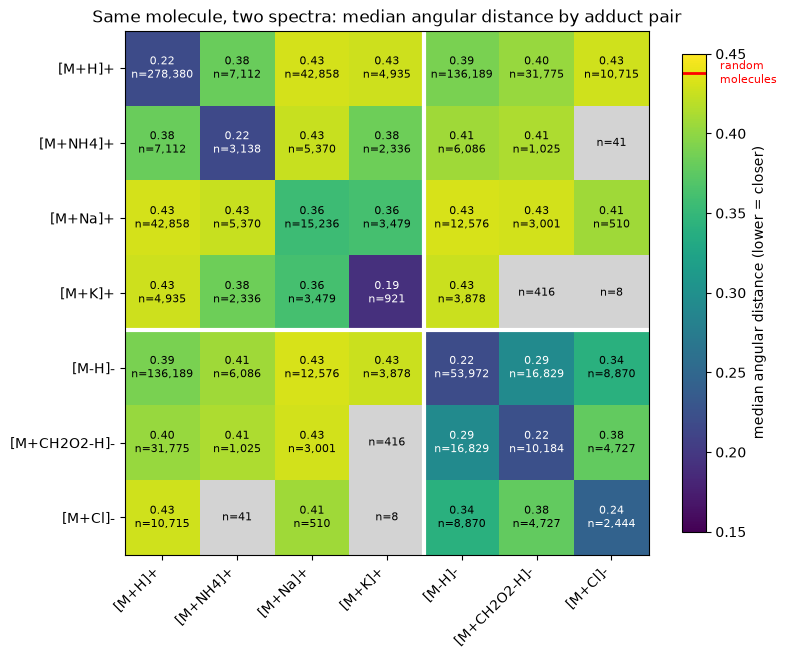

In [6]:
import matplotlib.pyplot as plt

MIN_PAIRS = 500  # cells with fewer pairs are greyed out

# Positive adducts first, then negative, so the two polarities form blocks
ADDUCT_ORDER = ["[M+H]+", "[M+NH4]+", "[M+Na]+", "[M+K]+",
                "[M-H]-", "[M+CH2O2-H]-", "[M+Cl]-"]
N_POSITIVE = 4

# Median distance and number of pairs for every adduct pair (no minimum here)
pair_stats = (
    pairs
    .group_by("adduct_1", "adduct_2")
    .agg(n_pairs=pl.len(), median=pl.col("angular_distance").median())
)

# Fill a symmetric matrix: (A, B) and (B, A) are the same pair type
n_adducts = len(ADDUCT_ORDER)
median_matrix = np.full((n_adducts, n_adducts), np.nan)
count_matrix = np.zeros((n_adducts, n_adducts), dtype=int)
for adduct_1, adduct_2, n_pairs, median in pair_stats.iter_rows():
    i = ADDUCT_ORDER.index(adduct_1)
    j = ADDUCT_ORDER.index(adduct_2)
    count_matrix[i, j] = n_pairs
    count_matrix[j, i] = n_pairs
    if n_pairs >= MIN_PAIRS:
        median_matrix[i, j] = median
        median_matrix[j, i] = median

fig, ax = plt.subplots(figsize=(8, 7))
colormap = plt.get_cmap("viridis").copy()
colormap.set_bad("lightgrey")  # NaN cells: too few pairs
image = ax.imshow(median_matrix, cmap=colormap, vmin=0.15, vmax=0.45)

# Median and pair count in each cell; white text on the dark (close) cells
for i in range(n_adducts):
    for j in range(n_adducts):
        if np.isnan(median_matrix[i, j]):
            label = f"n={count_matrix[i, j]:,}"
            text_color = "black"
        else:
            label = f"{median_matrix[i, j]:.2f}\nn={count_matrix[i, j]:,}"
            text_color = "white" if median_matrix[i, j] < 0.33 else "black"
        ax.text(j, i, label, ha="center", va="center", fontsize=8, color=text_color)

# Line between the positive and negative blocks
ax.axhline(N_POSITIVE - 0.5, color="white", linewidth=3)
ax.axvline(N_POSITIVE - 0.5, color="white", linewidth=3)

ax.set_xticks(range(n_adducts))
ax.set_xticklabels(ADDUCT_ORDER, rotation=45, ha="right")
ax.set_yticks(range(n_adducts))
ax.set_yticklabels(ADDUCT_ORDER)
ax.set_title("Same molecule, two spectra: median angular distance by adduct pair")

# Colour bar, with the random-pair reference marked on it
colorbar = fig.colorbar(image, ax=ax, shrink=0.8)
colorbar.set_label("median angular distance (lower = closer)")
random_median = np.median(random_distances)
colorbar.ax.axhline(random_median, color="red", linewidth=2)
colorbar.ax.text(1.6, random_median, "random\nmolecules", transform=colorbar.ax.get_yaxis_transform(),
                 va="center", fontsize=8, color="red")

fig.tight_layout()
plt.show()